### Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA

### Load Electricity Data

In [2]:
electricity_df = pd.read_csv('electricity_resid_AZ.csv')
print(electricity_df.shape)
print(electricity_df.columns.tolist())
electricity_df.head(10)

(207, 2)
['MY', 'Q']


,MY,Q
0,Jan-01,2063
1,Feb-01,1790
2,Mar-01,1690
3,Apr-01,1404
4,May-01,1984
5,Jun-01,2572
6,Jul-01,3052
7,Aug-01,3116
8,Sep-01,2837
9,Oct-01,2220


### Parse Dates and Set Index

In [6]:
electricity_df['MY'] = pd.to_datetime(electricity_df['MY'], format='%b-%y')
electricity_df.set_index('MY', inplace=True)
electricity_df = electricity_df.sort_index()
electricity_df.head()

,Q
MY,
2001-01-01,2063
2001-02-01,1790
2001-03-01,1690
2001-04-01,1404
2001-05-01,1984


### Load Climate Data

In [7]:
climate_df = pd.read_csv('climate_Phoenix_AZ.csv')
climate_df.head()

(332, 8)
['STATION', 'NAME', 'DATE', 'CLDD', 'DX32', 'DX70', 'DX90', 'HTDD']


,STATION,NAME,DATE,CLDD,DX32,DX70,DX90,HTDD
0,USW00023183,"PHOENIX AIRPORT, AZ US",1990-09,676,0,30,28,0
1,USW00023183,"PHOENIX AIRPORT, AZ US",1990-10,425,0,31,24,0
2,USW00023183,"PHOENIX AIRPORT, AZ US",1990-11,98,0,26,0,70
3,USW00023183,"PHOENIX AIRPORT, AZ US",1990-12,0,0,14,0,353
4,USW00023183,"PHOENIX AIRPORT, AZ US",1991-01,0,0,6,0,283


### Process Climate Data

In [8]:
climate_df['DATE'] = pd.to_datetime(climate_df['DATE'])
climate_df.set_index('DATE', inplace=True)
climate_df = climate_df.sort_index()
climate_df.head()

,STATION,NAME,CLDD,DX32,DX70,DX90,HTDD
DATE,,,,,,,
1990-09-01,USW00023183,"PHOENIX AIRPORT, AZ US",676,0,30,28,0
1990-10-01,USW00023183,"PHOENIX AIRPORT, AZ US",425,0,31,24,0
1990-11-01,USW00023183,"PHOENIX AIRPORT, AZ US",98,0,26,0,70
1990-12-01,USW00023183,"PHOENIX AIRPORT, AZ US",0,0,14,0,353
1991-01-01,USW00023183,"PHOENIX AIRPORT, AZ US",0,0,6,0,283


### Merge Electricity and Climate Data

In [9]:
merged_df = electricity_df.merge(
    climate_df,
    left_index=True,
    right_index=True,
    how='inner'
)

merged_df.head()

,Q,STATION,NAME,CLDD,DX32,DX70,DX90,HTDD
2001-01-01,2063,USW00023183,"PHOENIX AIRPORT, AZ US",0,0,11,0,339
2001-02-01,1790,USW00023183,"PHOENIX AIRPORT, AZ US",0,0,11,0,228
2001-03-01,1690,USW00023183,"PHOENIX AIRPORT, AZ US",108,0,23,2,90
2001-04-01,1404,USW00023183,"PHOENIX AIRPORT, AZ US",247,0,27,11,47
2001-05-01,1984,USW00023183,"PHOENIX AIRPORT, AZ US",679,0,31,27,0


### Exploratory Data Analysis

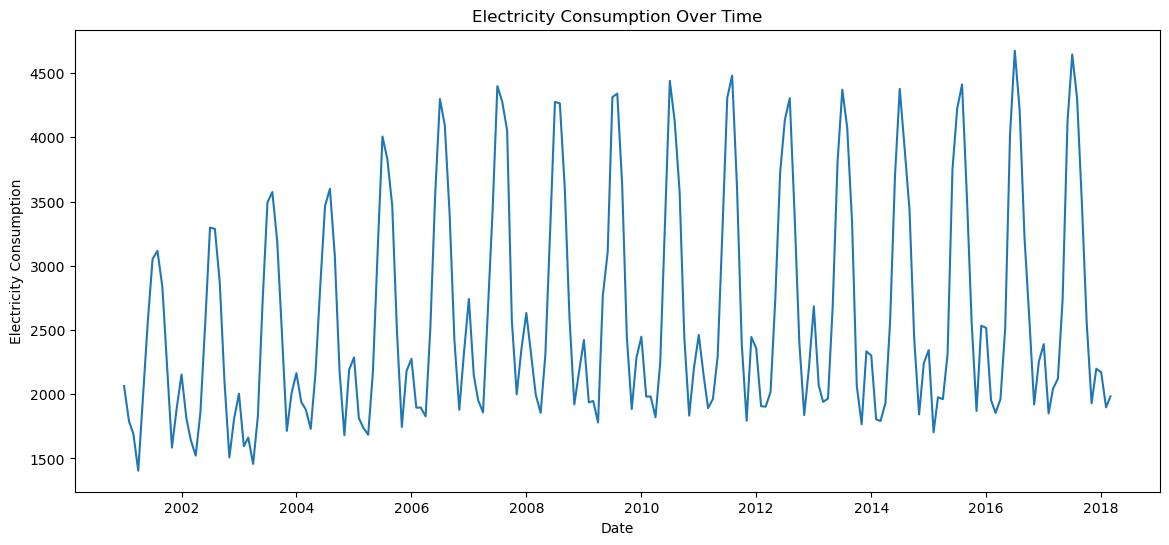

In [11]:
plt.figure(figsize=(14,6))
plt.plot(merged_df.index, merged_df['Q'])
plt.title('Electricity Consumption Over Time')
plt.xlabel('Date')
plt.ylabel('Electricity Consumption')
plt.show()

### Seasonal Decomposition

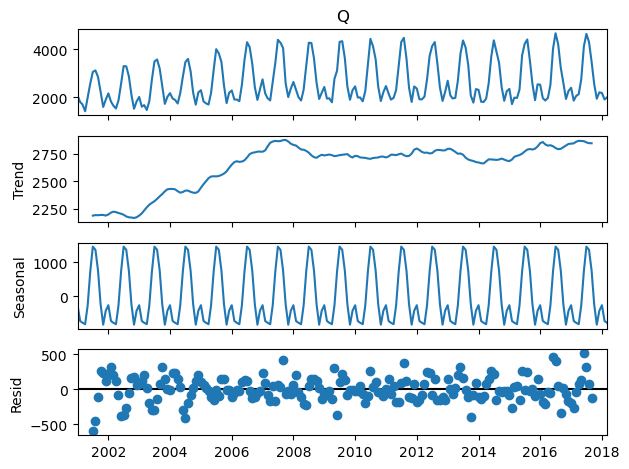

In [13]:
result = seasonal_decompose(
    merged_df['Q'],
    model='additive',
    period=12
)

result.plot()
plt.show()

### Stationarity Test (ADF)

In [15]:
result = adfuller(merged_df['Q'])
print('ADF Statistic:', result[0])
print('p-value:', result[1])

for key, value in result[4].items():
    print('Critical Values:')
    print(f'{key}, {value}')

ADF Statistic: -1.9886021677365142
p-value: 0.29159290414112793
Critical Values:
   1%, -3.4645146202692527
Critical Values:
   5%, -2.8765564361715534
Critical Values:
   10%, -2.5747745328940375


### Differencing

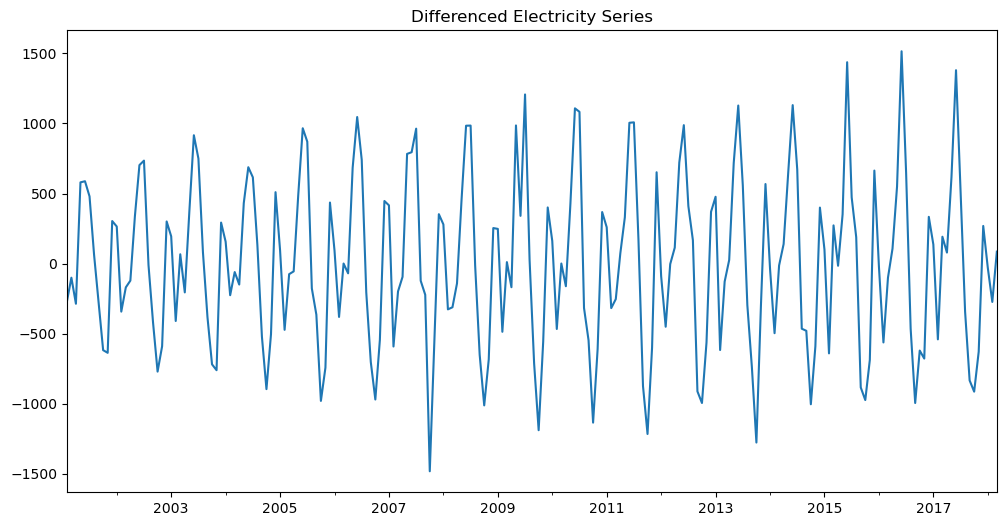

In [17]:
merged_df['electricity_diff'] = merged_df['Q'].diff()
merged_df['electricity_diff'].dropna().plot(figsize=(12,6))

plt.title('Differenced Electricity Series')
plt.show()

### ACF and PACF Plots

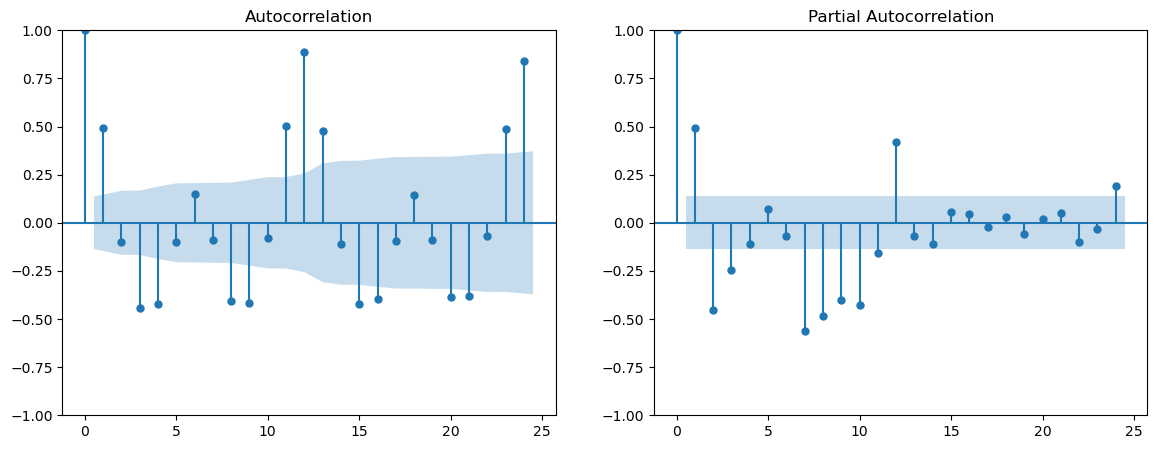

In [18]:
fig, ax = plt.subplots(1,2, figsize=(14,5))
plot_acf(merged_df['electricity_diff'].dropna(), ax=ax[0])
plot_pacf(merged_df['electricity_diff'].dropna(), ax=ax[1])

plt.show()

### Train/Test Split

In [19]:
train_size = int(len(merged_df) * 0.8)
train = merged_df.iloc[:train_size]
test = merged_df.iloc[train_size:]

### ARIMA Model

In [26]:
model = ARIMA(
    train['Q'],
    exog=train[['CLDD','HTDD','DX90']],
    order=(1,1,1)
)

model_fit = model.fit()

C:\Users\assan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\assan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\assan\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


### Forecast

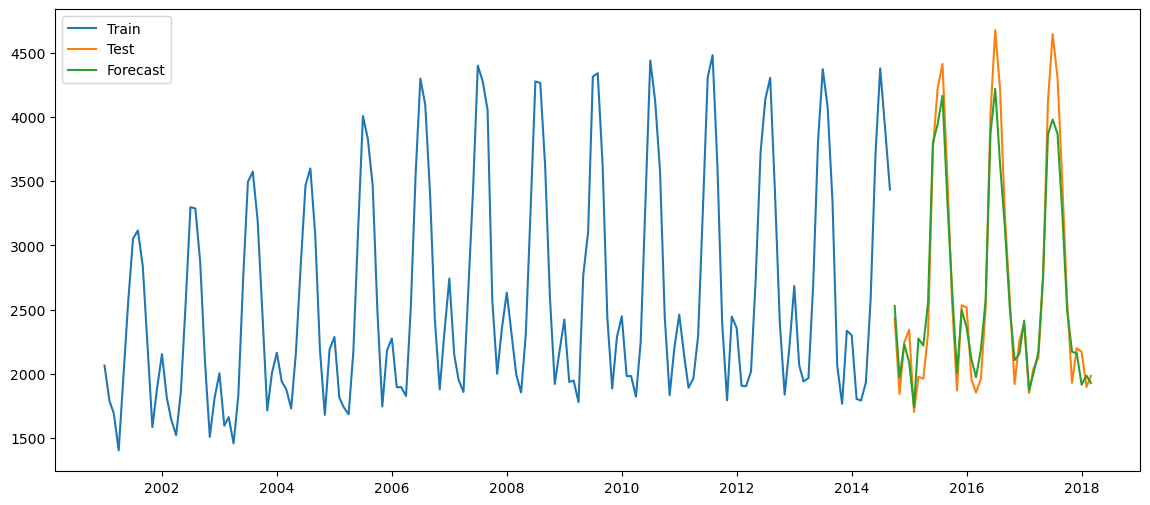

In [29]:
forecast = model_fit.forecast(
    steps=len(test),
    exog=test[['CLDD','HTDD','DX90']]
)

plt.figure(figsize=(14,6))
plt.plot(train.index, train['Q'], label='Train')
plt.plot(test.index, test['Q'], label='Test')
plt.plot(test.index, forecast, label='Forecast')
plt.legend()
plt.show()